In [1]:
# ── TEMPLATE DASHBOARD VISUALISASI STATIS ────────────────────────────
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('titanic') # ganti sesuai pilihan
print(df.shape, df.dtypes)
print(df.describe().round(2))


(891, 15) survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object
       survived  pclass     age   sibsp   parch    fare
count    891.00  891.00  714.00  891.00  891.00  891.00
mean       0.38    2.31   29.70    0.52    0.38   32.20
std        0.49    0.84   14.53    1.10    0.81   49.69
min        0.00    1.00    0.42    0.00    0.00    0.00
25%        0.00    2.00   20.12    0.00    0.00    7.91
50%        0.00    3.00   28.00    0.00    0.00   14.45
75%        1.00    3.00   38.00    1.00    0.00   31.00
max        1.00    3.00   80.00    8.00    6.00  512.33


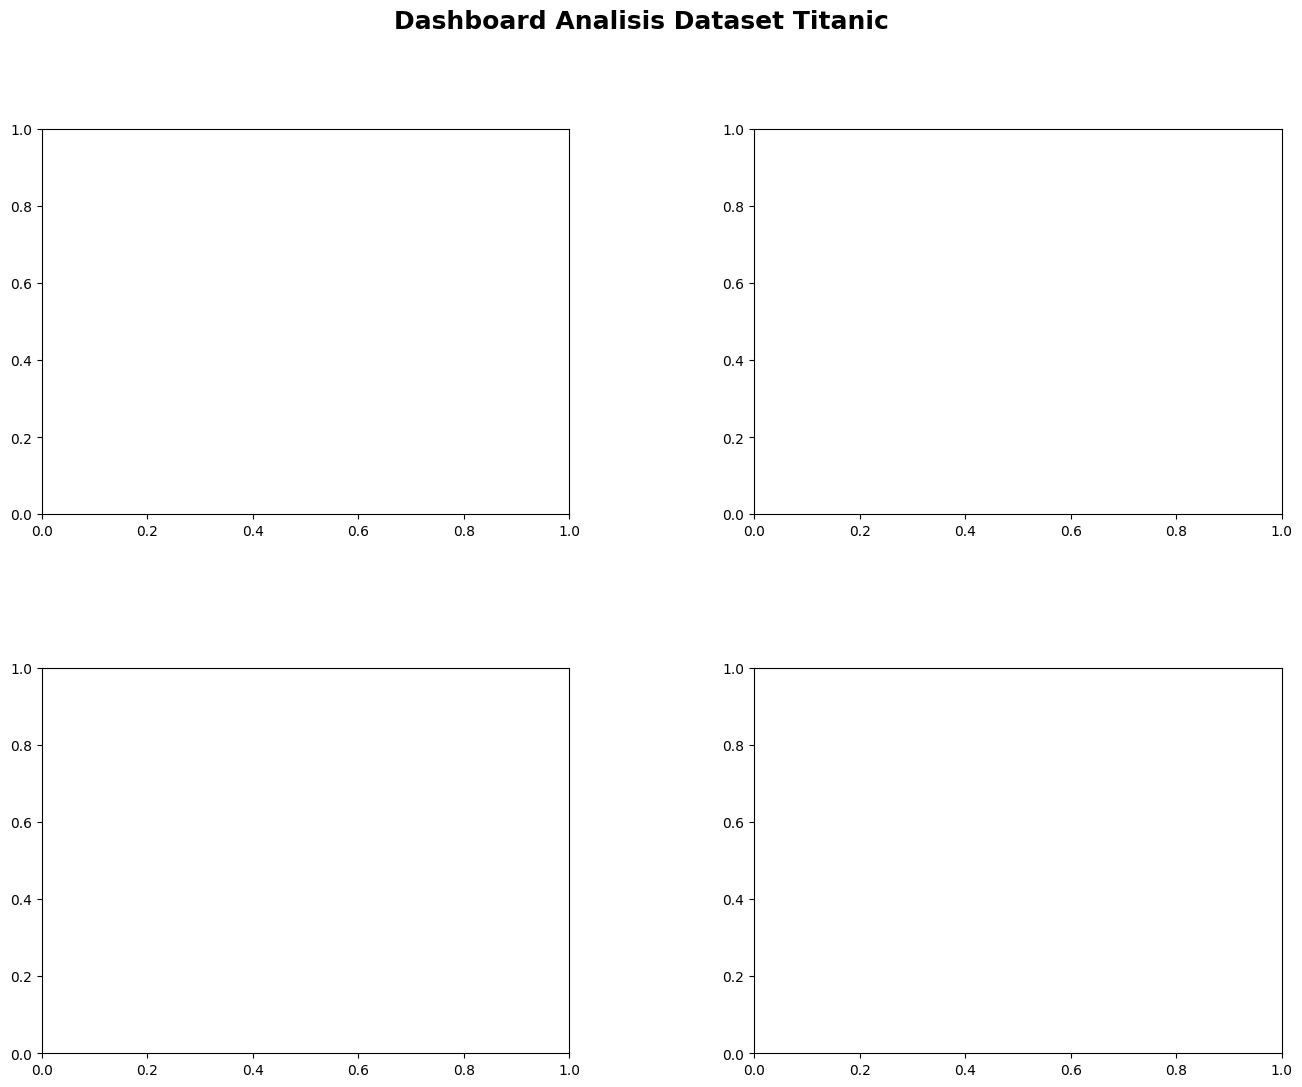

In [3]:
# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Titanic',
fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])  # kiri atas
ax2 = fig.add_subplot(gs[0, 1])  # kanan atas
ax3 = fig.add_subplot(gs[1, 0])  # kiri bawah
ax4 = fig.add_subplot(gs[1, 1])  # kanan bawah

In [4]:
# ── 3. GRAFIK 1: Bar Chart ─────────────────────────────────────────────
avg_survival_by_class = df.groupby('pclass')['survived'].mean()
avg_survival_by_class.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Tingkat Selamat per Kelas')
ax1.set_xlabel('Kelas'); ax1.set_ylabel('Tingkat Selamat')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)


In [5]:
# ── 4. GRAFIK 2: Histogram + KDE ───────────────────────────────────────
sns.histplot(data=df, x='age', hue='pclass', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Usia Penumpang per Kelas')
ax2.set_xlabel('Usia'); ax2.set_ylabel('Frekuensi')
ax2.spines[['top','right']].set_visible(False)

In [6]:
# ── 5. GRAFIK 3: Boxplot ───────────────────────────────────────────────
sns.boxplot(data=df, x='pclass', y='fare', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tarif per Kelas & Jenis Kelamin')
ax3.set_ylabel('Tarif (USD)')
ax3.spines[['top','right']].set_visible(False)

In [7]:
# ── 6. GRAFIK 4: Scatter Plot ──────────────────────────────────────────
sns.scatterplot(data=df, x='fare', y='age', hue='pclass', size='fare', sizes=(30, 180), palette='Set2', alpha=0.7, ax=ax4)
ax4.set_title('Hubungan Tarif & Usia Penumpang (Ukuran = Tarif)')
ax4.set_xlabel('Tarif (USD)'); ax4.set_ylabel('Usia')
ax4.spines[['top','right']].set_visible(False)

In [8]:
# ── 7. EKSPOR ──────────────────────────────────────────────────────────
plt.savefig('dashboard_titanic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_titanic.png')

<Figure size 640x480 with 0 Axes>

Dashboard tersimpan sebagai dashboard_titanic.png
